# 1 Installing the YOLOv8 Environment

To start off with YOLOv8 we first clone the YOLOv8 repository and install dependencies. This will set up our programming environment to be ready to running object detection training and inference commands.

In [1]:
# Clone repository
!git clone https://github.com/ultralytics/ultralytics

# Navigate to the cloned directory
%cd ultralytics

# Install the package in editable mode for development
!pip install -e .

C:\Users\CP1\Documents\GitHub\Itemized-Billing\ultralytics


fatal: destination path 'ultralytics' already exists and is not an empty directory.


Obtaining file:///C:/Users/CP1/Documents/GitHub/Itemized-Billing/ultralytics
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Attempting uninstall: ultralytics
    Found existing installation: ultralytics 8.0.165


ERROR: Cannot uninstall ultralytics 8.0.165, RECORD file not found. You might be able to recover from this via: 'pip install --force-reinstall --no-deps ultralytics==8.0.165'.


# 2 Import Libraries

In [2]:
import torch
print('torch %s %s' % (torch.__version__, torch.cuda.get_device_properties(0) if torch.cuda.is_available() else 'CPU'))
from ultralytics import YOLO

import yaml
import glob
from IPython.display import Image, display
from IPython.core.magic import register_line_cell_magic

from DataAugmentation import DataAugmentation

torch 1.13.1+cu116 _CudaDeviceProperties(name='NVIDIA GeForce RTX 3090', major=8, minor=6, total_memory=24575MB, multi_processor_count=82)


In [3]:
%cd ..

# Open and read the YAML file
with open('configuration/config-TCD.yaml', 'r') as file:
    yaml_data = yaml.safe_load(file)

yaml_data

C:\Users\CP1\Documents\GitHub\Itemized-Billing


{'path': 'C:/Users/CP1/Documents/GitHub/Itemized-Billing/TCD-yolo-1.1',
 'train': 'train.txt',
 'val': 'valid.txt',
 'nc': 2,
 'names': ['Row', 'Header']}

In [4]:
# Define number of classes based on YAML
with open('configuration/config-TCD.yaml', 'r') as stream:
    num_classes = str(yaml.safe_load(stream)['nc'])

print(f'Number of class: {num_classes}')

Number of class: 2


In [5]:
import os

current_directory = os.getcwd()
print("Current Directory:", current_directory)

Current Directory: C:\Users\CP1\Documents\GitHub\Itemized-Billing


# 3 Train YOLOv8

In [8]:
model = YOLO('yolov8s.pt')  # build a new model from scratch

results = model.train(data='configuration/config-TCD.yaml', epochs=1000, workers=1, imgsz=416)  # train the model

New https://pypi.org/project/ultralytics/8.0.196 available  Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.0.171  Python-3.10.10 torch-1.13.1+cu116 CUDA:0 (NVIDIA GeForce RTX 3090, 24576MiB)
WARNING  Upgrade to torch>=2.0.0 for deterministic training.
engine\trainer: task=detect, mode=train, model=yolov8s.pt, data=configuration/config-TCD.yaml, epochs=1000, patience=50, batch=16, imgsz=416, save=True, save_period=-1, cache=False, device=None, workers=1, project=None, name=None, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, show=False, save_txt=False, save_conf=False, save_crop=False, show_labels=True, show_conf=True, vid_st

# 4 Evaluate the model

In [9]:
results.results_dict

{'metrics/precision(B)': 0.9381874275221214,
 'metrics/recall(B)': 0.7659791370317686,
 'metrics/mAP50(B)': 0.91571211532076,
 'metrics/mAP50-95(B)': 0.5495433392530964,
 'fitness': 0.5861602168598627}

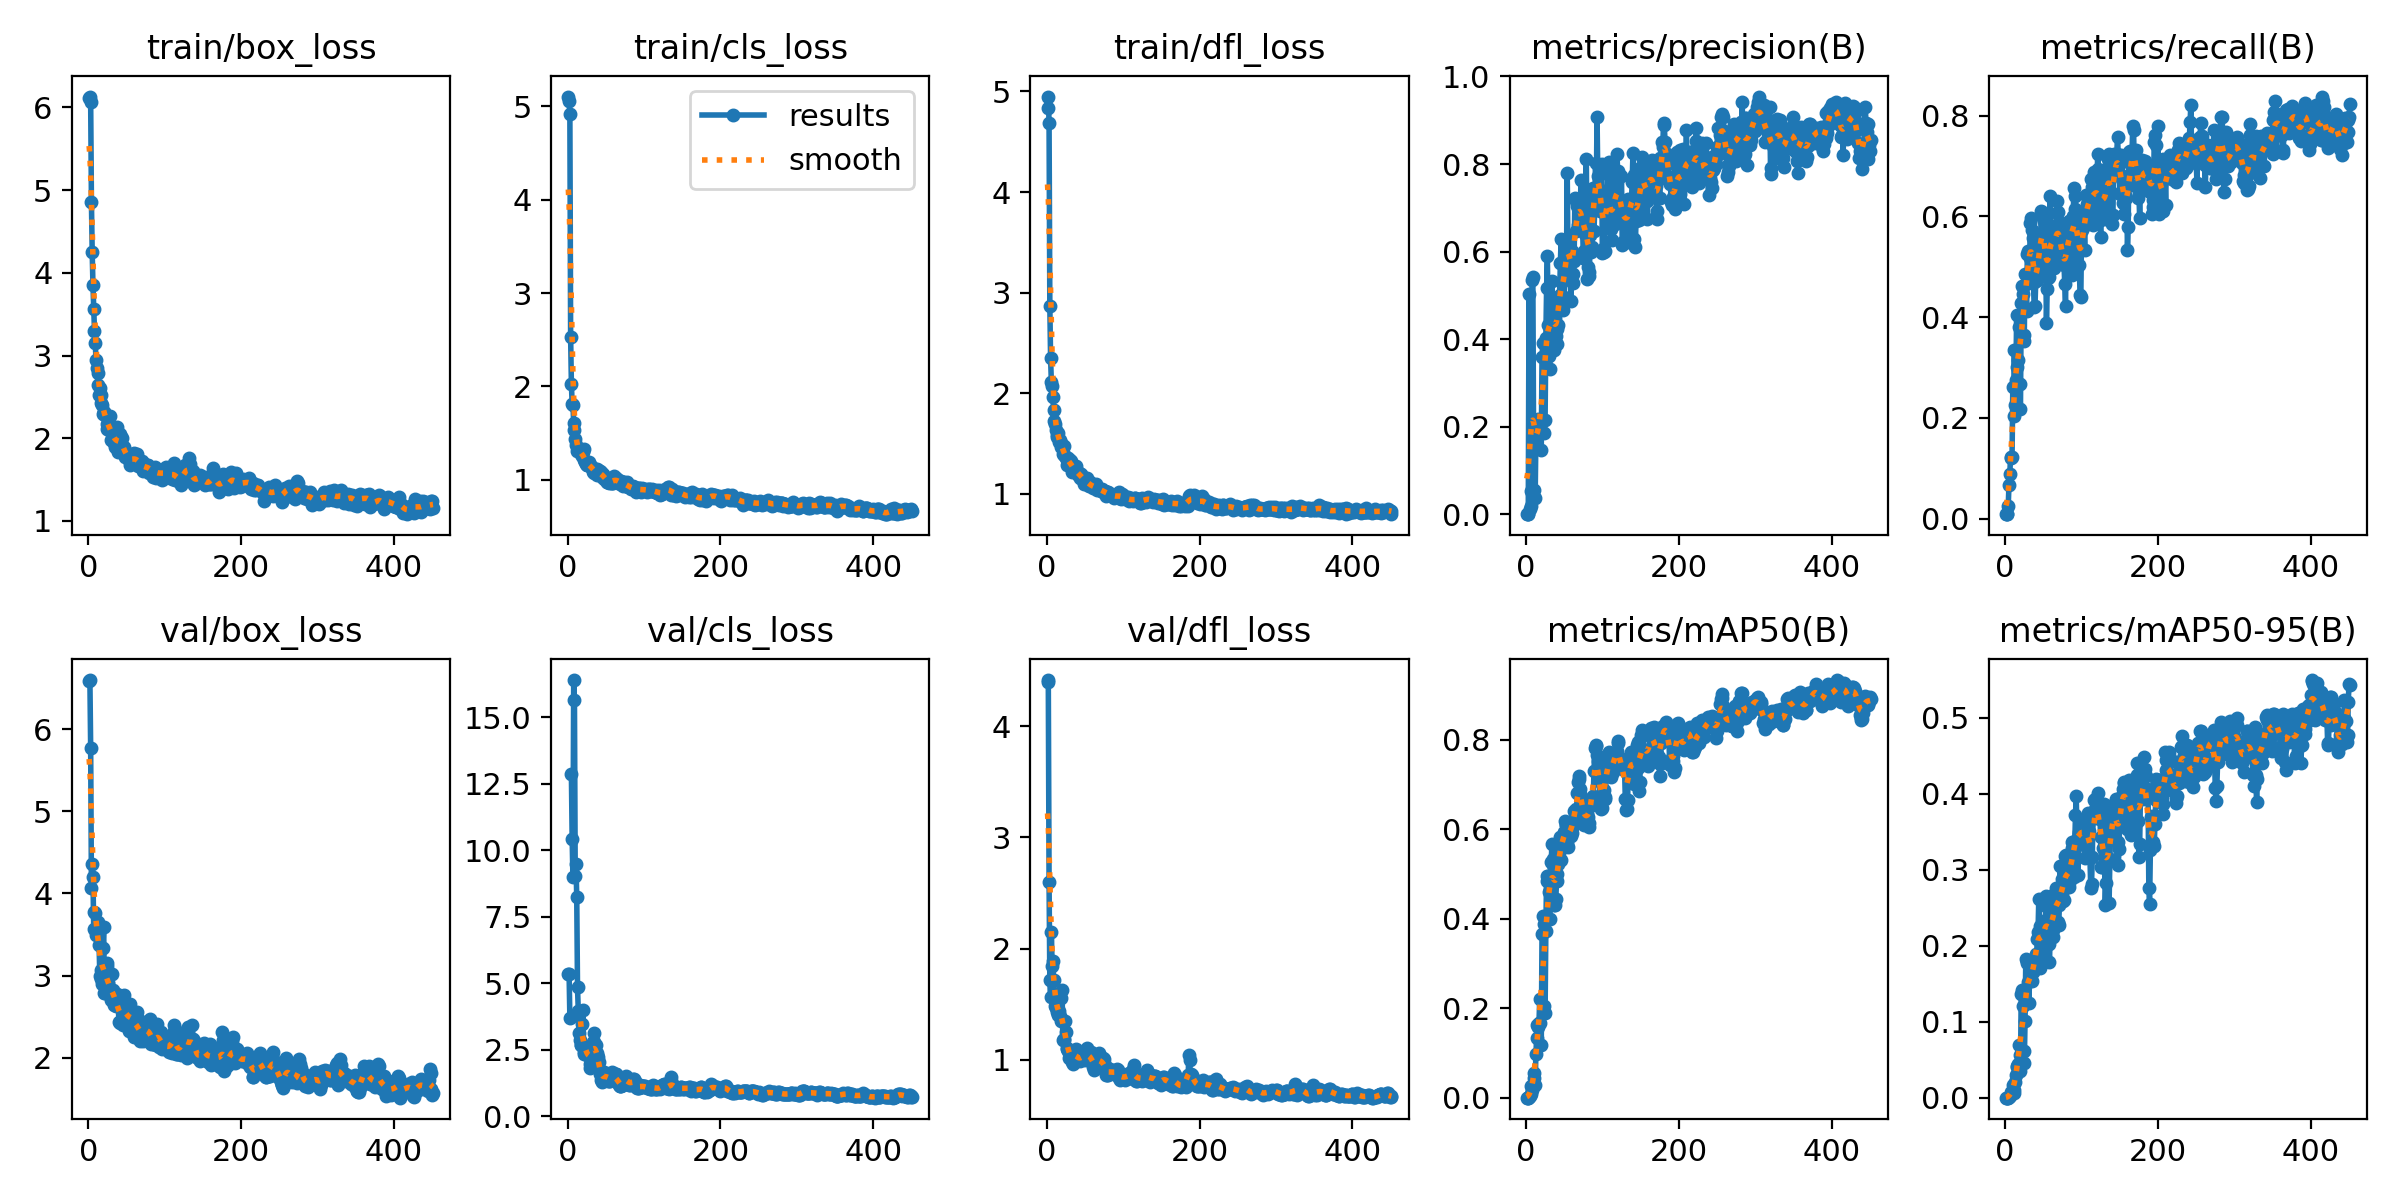

In [10]:
# We can also output some older school graphs if the tensor board isn't working for whatever reason...
Image(filename=f'{str(results.save_dir)}/results.png', width=1000)

## 4.1 Visualize the Training Data

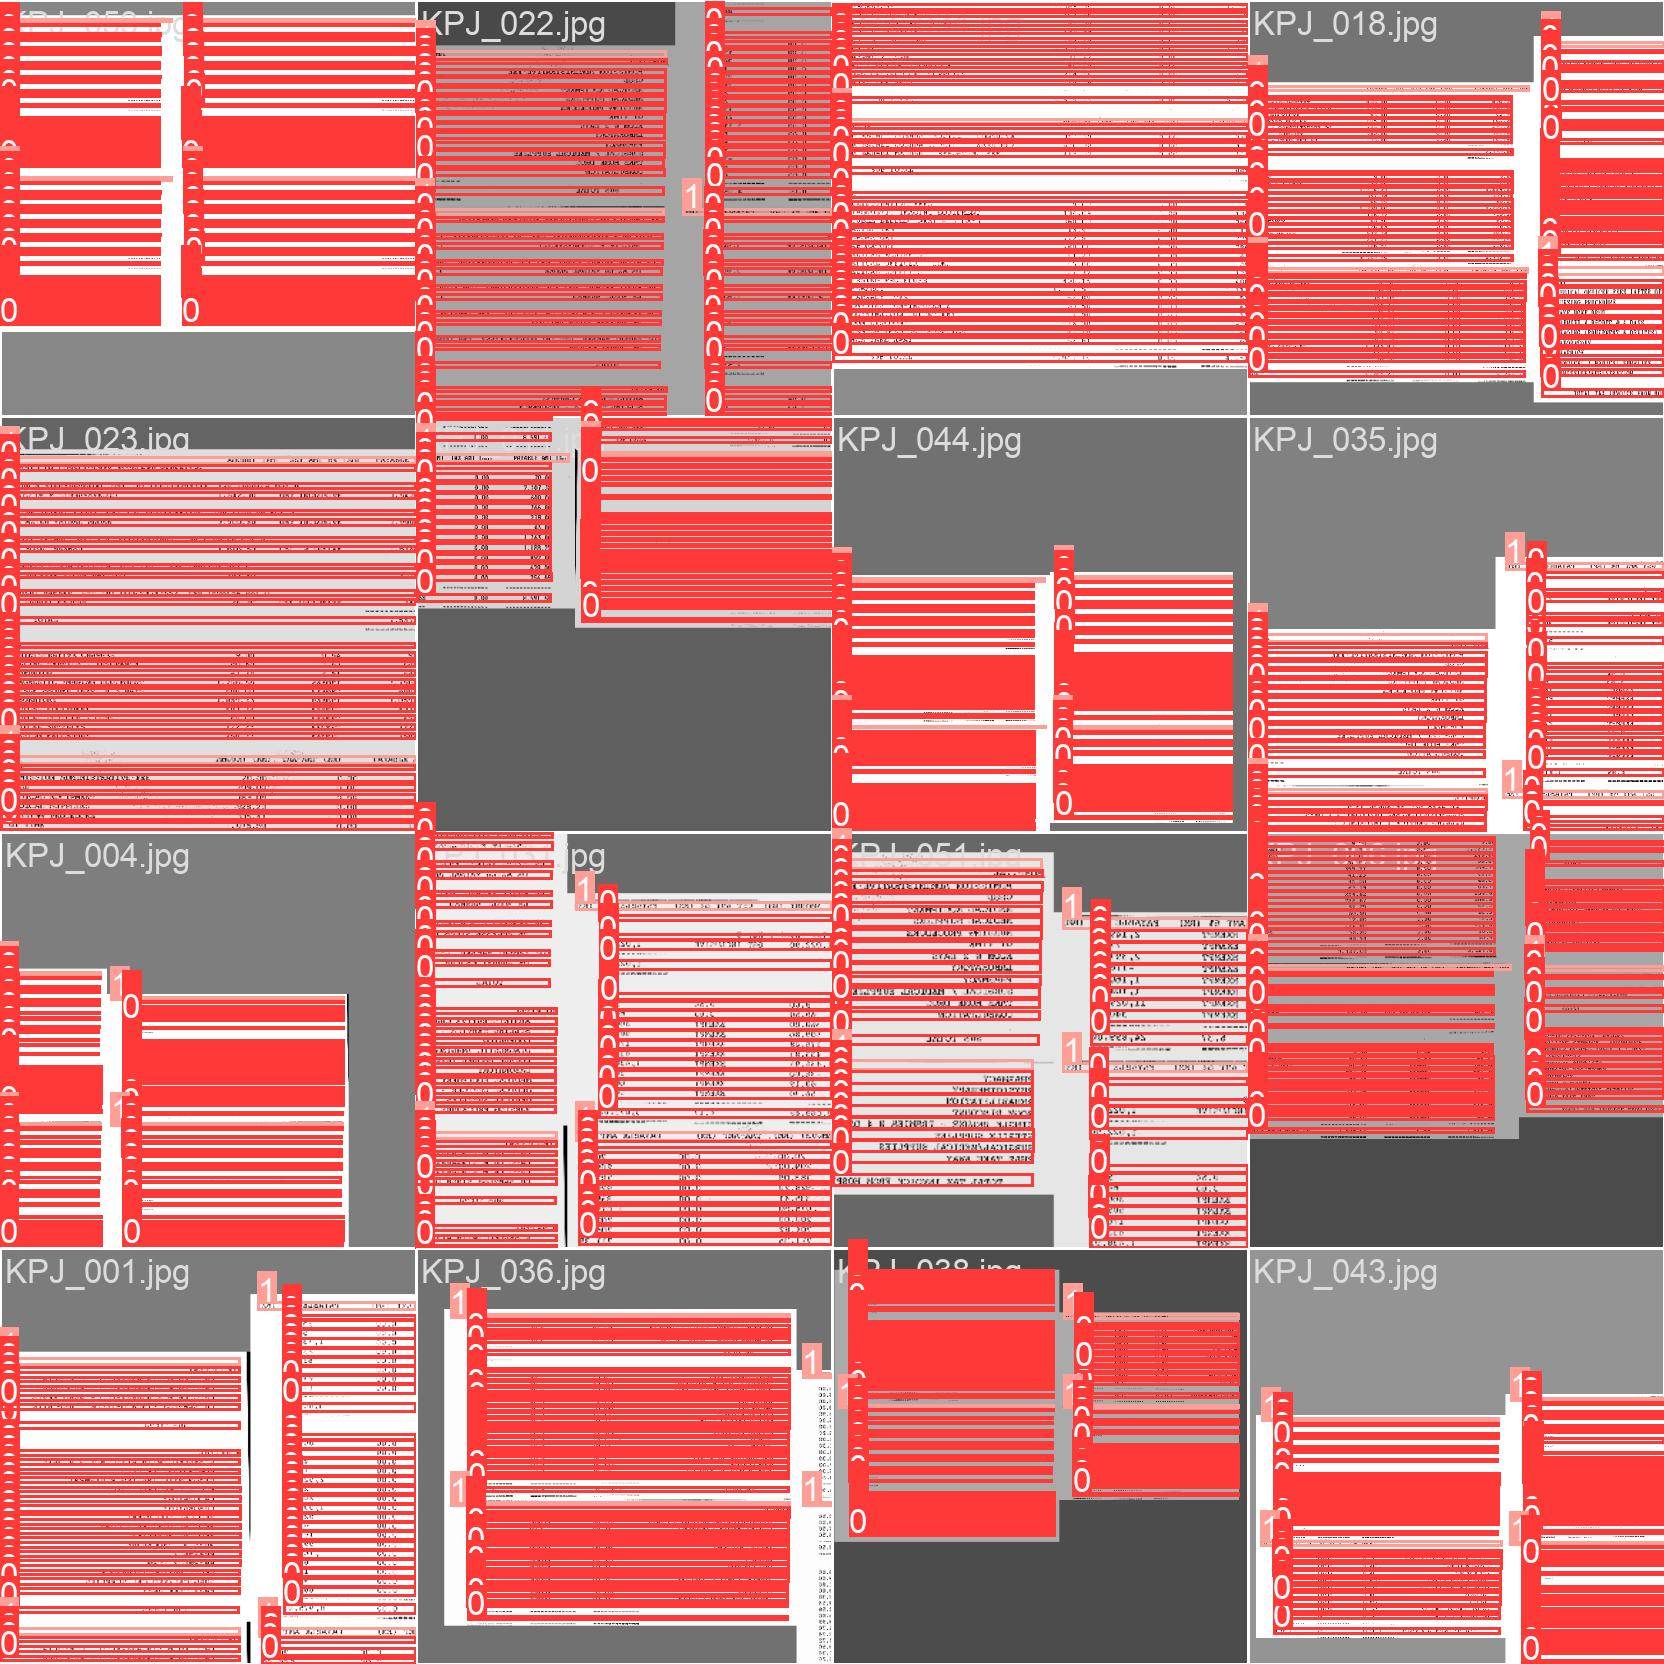

In [13]:
Image(filename=f'{str(results.save_dir)}/train_batch0.jpg', width=900)

## 4.2 Visualize the Labels of Validating Data

In [20]:
Image(filename=f'{str(results.save_dir)}/val_batch0_labels.jpg', width=900)

FileNotFoundError: [Errno 2] No such file or directory: 'runs\\detect\\train39/val_batch0_labels.jpg'

## 4.3 Visualize the Predicted Testing Data

In [ ]:
Image(filename=f'{str(results.save_dir)}/val_batch0_pred.jpg', width=900)

# 5 Run Inference  With Trained Weights
Run inference with a pretrained checkpoint on contents of `test/images` folder downloaded from Roboflow.


In [14]:
source = 'Crop_Images'
model = YOLO(f'{str(results.save_dir)}/weights/best.pt')
# model = YOLO('best.pt')

deskewer = DataAugmentation(source)
deskewer.processor()

prediction = model.predict(source=source, save=True, imgsz=416)

1. Crop_Images\KPJ_111.jpg
2. Crop_Images\KPJ_112.jpg
3. Crop_Images\KPJ_113.jpg
4. Crop_Images\KPJ_114.jpg
5. Crop_Images\KPJ_115.jpg
6. Crop_Images\KPJ_116.jpg
7. Crop_Images\KPJ_117.jpg
8. Crop_Images\KPJ_118.jpg
9. Crop_Images\KPJ_119.jpg
10. Crop_Images\KPJ_120.jpg
11. Crop_Images\KPJ_121.jpg
12. Crop_Images\KPJ_122.jpg
13. Crop_Images\KPJ_123.jpg
14. Crop_Images\KPJ_124.jpg
15. Crop_Images\KPJ_125.jpg
16. Crop_Images\KPJ_126.jpg
17. Crop_Images\KPJ_127.jpg
18. Crop_Images\KPJ_128.jpg
19. Crop_Images\KPJ_129.jpg
20. Crop_Images\KPJ_130.jpg



image 1/20 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\KPJ_111.jpg: 128x416 10 Rows, 1 Header, 78.3ms
image 2/20 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\KPJ_112.jpg: 224x416 35 Rows, 1 Header, 31.8ms
image 3/20 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\KPJ_113.jpg: 224x416 21 Rows, 31.7ms
image 4/20 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\KPJ_114.jpg: 192x416 28 Rows, 47.3ms
image 5/20 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\KPJ_115.jpg: 192x416 21 Rows, 1 Header, 31.7ms
image 6/20 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\KPJ_116.jpg: 288x416 37 Rows, 1 Header, 14.5ms
image 7/20 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\KPJ_117.jpg: 192x416 19 Rows, 1 Header, 15.6ms
image 8/20 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\KPJ_118.jpg: 256x416 44 Rows, 1 Header, 15.7ms
image 9/20 C:\Users\CP1\Documents\GitHub\Itemized-Billing\Crop_Images\KPJ_119.jpg: 